In [36]:
import os
import h5py
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, resample_poly, find_peaks
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

In [46]:
dirs = [
    r"D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs",  # BLA alone
    r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs",  # BLA CM
    r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs"  # AIM1 CM
]

h5_files = []

for d in dirs:
    if not os.path.exists(d):
        print(f"⚠️ Missing directory: {d}")
        continue

    files = [
        os.path.join(d, f)
        for f in os.listdir(d)
        if f.endswith(".h5")
    ]

    print(f"{d} → {len(files)} files")
    h5_files.extend(files)

# remove duplicates + sort
h5_files = sorted(list(set(h5_files)))

print("\nTOTAL FILES:", len(h5_files))
print("Example:", h5_files[:5])

D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs → 22 files
D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs → 24 files
E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs → 8 files

TOTAL FILES: 54
Example: ['D:\\BLA_ChR_resp\\BLA_resp_ChR_bl_cc\\h5_outputs\\1_1_bl_cc_20260105_151056.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_bl_cc\\h5_outputs\\1_2_bl_cc_20260105_202137.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_bl_cc\\h5_outputs\\1_3_bl_cc_20260105_172919.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_bl_cc\\h5_outputs\\2_1_bl_cc_20260105_142514.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_bl_cc\\h5_outputs\\2_2_bl_cc_20260105_193029.h5']


In [47]:
# -------------------------
# Split datasets
# -------------------------
aim1_files = [f for f in h5_files if "Aim1" in f]
bla_cm_files = [f for f in h5_files if "cm" in os.path.basename(f).lower()]
bla_alone_files = [f for f in h5_files if "bl_cc" in os.path.basename(f).lower()]

print("\nAIM1:", len(aim1_files))
print("BLA CM:", len(bla_cm_files))
print("BLA Alone:", len(bla_alone_files))


AIM1: 8
BLA CM: 31
BLA Alone: 22


In [48]:
model_files = aim1_files + bla_cm_files

In [49]:
rank_map_bla = {
    "1_1": "Intermediate",
    "1_2": "Dominant",
    "1_3": "Subordinate",
    "2_1": "Dominant",
    "2_2": "Subordinate",
    "2_3": "Intermediate",
    "3_1": "Intermediate",
    "3_2": "Dominant",
    "3_3": "Subordinate",
    "4_1": "Subordinate",
    "4_2": "Dominant",
    "4_3": "Dominant",
    "5_1": "Intermediate",
    "5_2": "Dominant",
    "5_3": "Subordinate",
    "6_2": "Dominant",
    "6_3": "Subordinate",
    "7_1": "Dominant",
    "7_2": "Subordinate",
    "8_1": "Dominant",
    "8_2": "Subordinate",
}

In [50]:
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

In [55]:
def load_clean_resp_signal(h5_file, target_rate=100):

    try:
        with h5py.File(h5_file, 'r') as f:

            keys = list(f.keys())

            # -------------------------
            # BLA format (resp_clean)
            # -------------------------
            if "resp_clean" in keys:
                signal = f["resp_clean"]["signal"][:]
                time = f["resp_clean"]["time"][:]

                return signal, time, target_rate, {"source": "BLA"}

            # -------------------------
            # AIM1 format (resp)
            # -------------------------
            elif "resp" in keys:
                resp = f["resp"][:].flatten()

                metadata = {}
                if "resp_metadata" in f:
                    metadata.update(dict(f["resp_metadata"].attrs))
                if "metadata" in f:
                    metadata.update(dict(f["metadata"].attrs))

                # sampling rate
                if "sampling_frequency" in metadata:
                    fs = metadata["sampling_frequency"]
                else:
                    duration_sec = metadata.get("duration_sec", None)
                    fs = len(resp) / duration_sec if duration_sec else 20000.0

                # filter + downsample
                from scipy.signal import butter, filtfilt, resample_poly

                nyquist = fs / 2
                cutoff = target_rate / 2
                b, a = butter(4, cutoff / nyquist, btype='low')
                filtered = filtfilt(b, a, resp)

                down_factor = int(round(fs / target_rate))
                down = resample_poly(filtered, up=1, down=down_factor)

                time = np.arange(len(down)) / target_rate

                return down, time, target_rate, metadata

            else:
                print(f"⚠️ Unknown format: {h5_file} | keys={keys}")
                return None, None, None, None

    except Exception as e:
        print(f"❌ Error loading {h5_file}: {e}")
        return None, None, None, None

In [56]:
def get_instantaneous_resp_rate(signal, time, sampling_rate=100):

    peaks, _ = find_peaks(signal, distance=int(sampling_rate * 0.0833))

    if len(peaks) < 2:
        return np.array([])

    peak_times = time[peaks]
    ibi = np.diff(peak_times)
    inst_rate = 1.0 / ibi

    return inst_rate

In [53]:
def sample_random_resp_windows(signal, time, fs, window_sec=2.0, n_samples=100):

    window_len = int(window_sec * fs)
    possible_starts = np.arange(0, len(signal) - window_len, window_len)

    if len(possible_starts) == 0:
        return []

    starts = np.random.choice(
        possible_starts,
        size=min(n_samples, len(possible_starts)),
        replace=False
    )

    rates = []

    for start in starts:
        stop = start + window_len
        sig = signal[start:stop]
        t = time[start:stop]

        inst_rate = get_instantaneous_resp_rate(sig, t, fs)

        if len(inst_rate) > 0:
            rates.append(np.mean(inst_rate))

    return rates

In [67]:
import re

rows = []

for h5_path in aim1_files:

    trial = os.path.basename(h5_path).replace(".h5", "")

    signal, time, fs, meta = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    rates = sample_random_resp_windows(signal, time, fs)

    parts = trial.split("_")

    subject = None
    partner = None
    rank = np.nan

    # =====================
    # AIM1 (uses rank_map)
    # =====================
    if "Aim1" in h5_path:

        subj_match = re.search(r"s(\d+)_(\d+)", trial)
        if subj_match:
            subject = f"{subj_match.group(1)}_{subj_match.group(2)}"

        partner_match = re.search(r"d(\d+)_(\d+)", trial)
        if partner_match:
            partner = f"{partner_match.group(1)}_{partner_match.group(2)}"

        rank = rank_map.get(subject, np.nan)
        condition = "CM"

    # =====================
    # BLA (uses rank_map_bla)
    # =====================
    elif "cm" in trial.lower():

        subject = f"{parts[0]}_{parts[1]}"

        if len(parts) >= 6:
            partner = f"{parts[4]}_{parts[5]}"

        rank = rank_map_bla.get(subject, np.nan)
        condition = "CM"

    else:
        continue  # skip non-CM files

    # =====================
    # pair
    # =====================
    pair = None
    if subject and partner:
        pair = "_".join(sorted([subject, partner]))

    # =====================
    # store
    # =====================
    for r in rates:
        rows.append({
            "Trial": trial,
            "Subject": subject,
            "Partner": partner,
            "Pair": pair,
            "Condition": condition,
            "Rank": rank,
            "RespRate": r
        })

df = pd.DataFrame(rows)

print(df.shape)
print(df.head())
df

(800, 7)
                                 Trial Subject Partner     Pair Condition  \
0  CM_s1_1_d1_2_20250623_111352_merged     1_1     1_2  1_1_1_2        CM   
1  CM_s1_1_d1_2_20250623_111352_merged     1_1     1_2  1_1_1_2        CM   
2  CM_s1_1_d1_2_20250623_111352_merged     1_1     1_2  1_1_1_2        CM   
3  CM_s1_1_d1_2_20250623_111352_merged     1_1     1_2  1_1_1_2        CM   
4  CM_s1_1_d1_2_20250623_111352_merged     1_1     1_2  1_1_1_2        CM   

          Rank  RespRate  
0  Subordinate  4.238287  
1  Subordinate  5.300449  
2  Subordinate  7.097263  
3  Subordinate  7.287804  
4  Subordinate  7.955405  


,Trial,Subject,Partner,Pair,Condition,Rank,RespRate
0,CM_s1_1_d1_2_20250623_111352_merged,1_1,1_2,1_1_1_2,CM,Subordinate,4.238287
1,CM_s1_1_d1_2_20250623_111352_merged,1_1,1_2,1_1_1_2,CM,Subordinate,5.300449
2,CM_s1_1_d1_2_20250623_111352_merged,1_1,1_2,1_1_1_2,CM,Subordinate,7.097263
3,CM_s1_1_d1_2_20250623_111352_merged,1_1,1_2,1_1_1_2,CM,Subordinate,7.287804
4,CM_s1_1_d1_2_20250623_111352_merged,1_1,1_2,1_1_1_2,CM,Subordinate,7.955405
...,...,...,...,...,...,...,...
795,CM_s4_8_sub4_7_20250623_182649_merged,4_8,None,None,CM,Dominant,8.165135
796,CM_s4_8_sub4_7_20250623_182649_merged,4_8,None,None,CM,Dominant,7.260461
797,CM_s4_8_sub4_7_20250623_182649_merged,4_8,None,None,CM,Dominant,9.678486
798,CM_s4_8_sub4_7_20250623_182649_merged,4_8,None,None,CM,Dominant,8.137126


In [65]:
model_files = aim1_files

In [66]:
df = df[df["Rank"].isin(["Dominant","Subordinate"])].copy()

print(df.shape)
print(df["Rank"].value_counts())
print(df["Subject"].unique())

(3300, 7)
Rank
Dominant       1700
Subordinate    1600
Name: count, dtype: int64
['1_1' '1_2' '2_3' '2_4' '3_5' '3_6' '4_7' '4_8' '1_3' '2_1' '2_2' '3_2'
 '3_3' '4_1' '4_2' '4_3' '6_2' '7_1' '7_2' '8_1' '8_2']


In [61]:
# =====================
# FIX COHORT + SUBJECT ID
# =====================

# define cohort
cohort = "1" if "Aim1" in h5_path else "2"

# keep original subject for rank mapping
subject_raw = subject

# update subject with cohort
subject = f"{subject_raw}_{cohort}" if subject_raw else None

# update partner with cohort
if partner:
    partner = f"{partner}_{cohort}"

# rebuild pair (important)
pair = None
if subject and partner:
    pair = "_".join(sorted([subject, partner]))

In [62]:
print(df["Subject"].unique()[:10])
print(df["Rank"].value_counts())

['1_1' '1_2' '2_3' '2_4' '3_5' '3_6' '4_7' '4_8' '1_3' '2_1']
Rank
Dominant        1700
Subordinate     1600
Intermediate     600
Name: count, dtype: int64


In [63]:
df = df[df["Rank"].isin(["Dominant", "Subordinate"])].copy()

print(df["Rank"].value_counts())

Rank
Dominant       1700
Subordinate    1600
Name: count, dtype: int64


In [8]:
import h5py

for f in h5_files[:5]:
    with h5py.File(f, "r") as h:
        print(f)
        print(list(h.keys()))

D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\1_1_bl_cc_20260105_151056.h5
['analog', 'dio', 'resp_clean', 'time']
D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\1_2_bl_cc_20260105_202137.h5
['analog', 'dio', 'resp_clean', 'time']
D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\1_3_bl_cc_20260105_172919.h5
['analog', 'dio', 'resp_clean', 'time']
D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\2_1_bl_cc_20260105_142514.h5
['analog', 'dio', 'resp_clean', 'time']
D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\2_2_bl_cc_20260105_193029.h5
['analog', 'dio', 'resp_clean', 'time']


In [12]:
aim1_files = [f for f in h5_files if "Aim1" in f]

print(len(aim1_files))
print(aim1_files[:3])

8
['E:\\Aim1\\AIM1\\Day1_new\\resp_CM_h5\\baseline_cagemate_interactions_h5_outputs\\CM_s1_1_d1_2_20250623_111352_merged.h5', 'E:\\Aim1\\AIM1\\Day1_new\\resp_CM_h5\\baseline_cagemate_interactions_h5_outputs\\CM_s1_2_sub1_1_20250623_133932_merged.h5', 'E:\\Aim1\\AIM1\\Day1_new\\resp_CM_h5\\baseline_cagemate_interactions_h5_outputs\\CM_s2_3_d2_4_20250623_151153_merged.h5']


In [13]:
import h5py

test_file = aim1_files[0]  # from your AIM1 directory

In [15]:
with h5py.File(test_file, "r") as f:
    print("Top-level keys:", list(f.keys()))
    
    for key in f.keys():
        print(f"\n--- {key} ---")
        
        obj = f[key]
        
        if isinstance(obj, h5py.Group):
            print("Subkeys:", list(obj.keys()))
        else:
            print("Shape:", obj.shape)

Top-level keys: ['ekg_metadata', 'metadata', 'resp', 'resp_metadata']

--- ekg_metadata ---
Subkeys: []

--- metadata ---
Subkeys: []

--- resp ---
Shape: (12252312,)

--- resp_metadata ---
Subkeys: []


In [7]:
with h5py.File(test_file, "r") as f:
    for key in f.keys():
        print(f"\n--- {key} ---")
        print(list(f[key].keys()))


--- analog ---
['1_1_bl_cc_20260105_151056.analog_ECU_Ain1', '1_1_bl_cc_20260105_151056.timestamps']

--- dio ---
[]

--- resp_clean ---
['signal', 'time']

--- time ---
['1_1_bl_cc_20260105_151056.timestamps']


In [5]:
import h5py

def load_clean_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        
        # 🔥 use preprocessed signal
        signal = f["resp_clean"]["signal"][()]
        time = f["resp_clean"]["time"][()]
        
    return signal, time

In [6]:
sessions = {}

for h5_path in h5_files:
    name = os.path.basename(h5_path).replace(".h5", "")
    
    try:
        signal, time = load_clean_h5(h5_path)
        sessions[name] = {"signal": signal, "time": time}
    except Exception as e:
        print("Skipping:", name, e)

print("Loaded:", len(sessions))

Skipping: CM_s1_1_d1_2_20250623_111352_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s1_2_sub1_1_20250623_133932_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s2_3_d2_4_20250623_151153_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s2_4_sub2_3_20250623_143348_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s3_5_d3_6_20250623_170708_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s3_6_sub3_5_20250623_174348_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s4_7_d4_8_20250623_193718_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Skipping: CM_s4_8_sub4_7_20250623_182649_merged "Unable to synchronously open object (object 'resp_clean' doesn't exist)"
Loaded: 46


In [23]:
import matplotlib.pyplot as plt

def plot_qc(session):
    sig = session["signal"]
    t = session["time"]
    
    plt.figure(figsize=(10,3))
    plt.plot(t, sig)
    plt.title("Resp signal QC")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

1_1_i_cm_1_2_d_20260106_134350


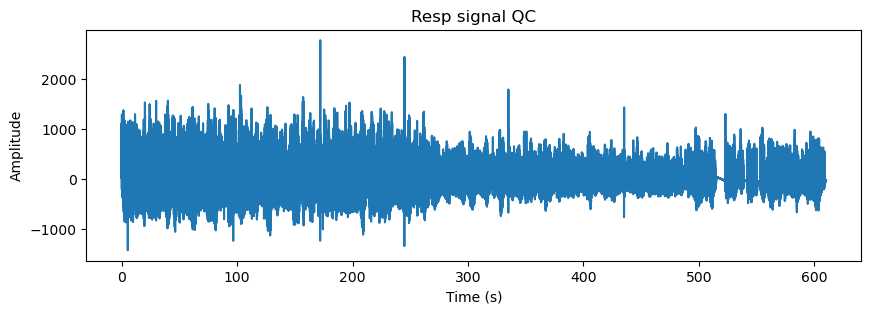

1_1_i_cm_1_3_s_20260107_163611


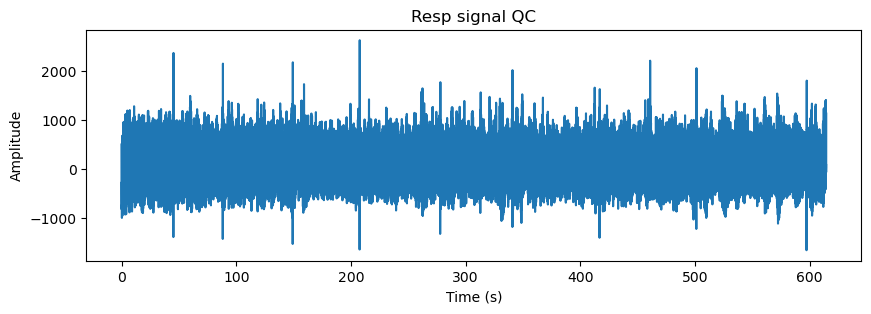

1_2_d_cm_1_3_s_20260108_114416


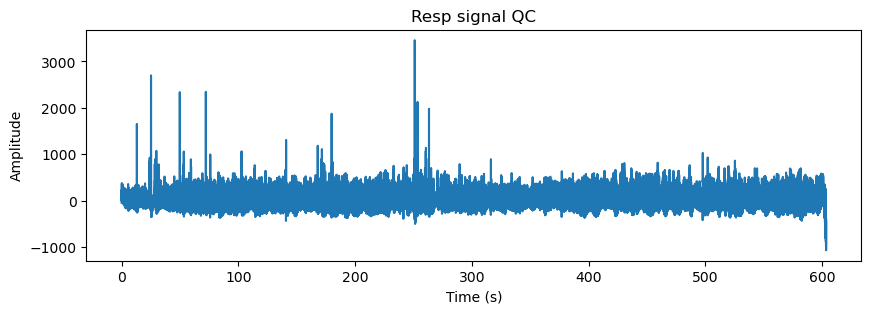

In [24]:
for k in list(sessions.keys())[:3]:
    print(k)
    plot_qc(sessions[k])

In [25]:
good_sessions = {}

for k, s in sessions.items():
    if np.std(s["signal"]) > 20:   # your threshold
        good_sessions[k] = s
    else:
        print("❌ BAD:", k)

print("Good sessions:", len(good_sessions))

Good sessions: 24


In [26]:
from scipy.signal import find_peaks

def compute_inst_rate(signal, time, fs=100):
    
    peaks, _ = find_peaks(signal, distance=fs*0.08)
    
    peak_times = time[peaks]
    
    ibi = np.diff(peak_times)
    
    inst_rate = 1 / ibi
    inst_time = peak_times[:-1]
    
    return inst_time, inst_rate

In [27]:
inst_rate_sessions = {}

for name, s in good_sessions.items():
    
    try:
        t, r = compute_inst_rate(s["signal"], s["time"])
        
        inst_rate_sessions[name] = {
            "time": t,
            "rate": r
        }
        
    except Exception as e:
        print("Skipping:", name, e)

print("Processed:", len(inst_rate_sessions))

Processed: 24


In [47]:
import pandas as pd
import numpy as np

session_rows = []

for name, data in inst_rate_sessions.items():
    
    rate = data["rate"]
    
    # 🔥 clean bad values (important)
    rate = rate[(rate > 0.5) & (rate < 10)]
    
    if len(rate) == 0:
        continue
    
    session_rows.append({
        "Session": name,
        "MeanRate": np.mean(rate),
        "MedianRate": np.median(rate),   # optional but useful
        "N_points": len(rate)
    })

session_df = pd.DataFrame(session_rows)

print(session_df.shape)
session_df

(24, 4)


,Session,MeanRate,MedianRate,N_points
0,1_1_i_cm_1_2_d_20260106_134350,7.705390,8.333333,2607
1,1_1_i_cm_1_3_s_20260107_163611,7.791370,8.333333,2748
2,1_2_d_cm_1_3_s_20260108_114416,7.887456,8.333333,3310
3,1_3_s_1_2_d_20260107_165340,7.575819,7.692308,3225
4,1_3_s_cm_1_1_i_20260106_122823,7.834552,8.333333,3158
5,2_1_d_cm_2.3_i_20260106_105109,7.753240,8.333333,2860
6,2_1_d_cm_2_2_s_20260108_112426,7.829205,8.333333,2926
7,2_2_s_cm_2_1_d_20260108_120453,7.780801,8.333333,2570
8,2_2_s_cm_2_3_i_20260106_132549,8.046291,8.333333,2767
9,3_1_i_cm_3_2_d_20260106_115157,7.712347,8.333333,2700


In [43]:
session_df["Subject"] = session_df["Session"].apply(
    lambda x: "_".join(x.split("_")[0:2])
)

In [44]:
session_df["RankLabel"] = session_df["Subject"].map(rank_map_bla)

In [45]:
session_df = session_df.dropna(subset=["RankLabel"])

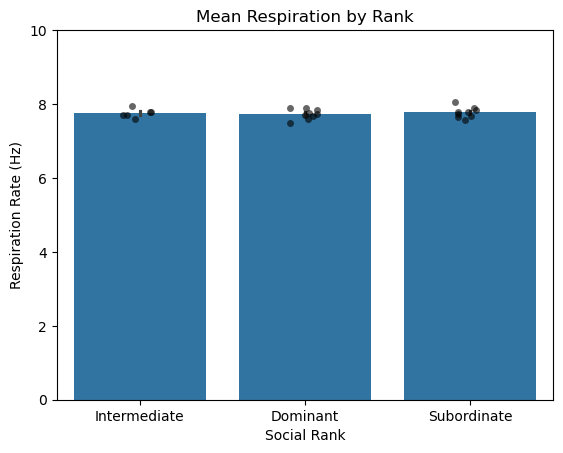

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=session_df,
    x="RankLabel",
    y="MeanRate",
    errorbar="se"
)

sns.stripplot(
    data=session_df,
    x="RankLabel",
    y="MeanRate",
    color="black",
    alpha=0.6
)

plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("Social Rank")
plt.ylim(0,10)
plt.title("Mean Respiration by Rank")

plt.show()

In [1]:
import numpy as np
from scipy.signal import find_peaks


def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12,
    min_rate_hz=0.5
):

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Center signal
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI → rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)

    inst_rate = 1.0 / ibi

    # -----------------------------
    # 🔥 FILTER BAD VALUES
    # -----------------------------
    inst_rate = inst_rate[
        (inst_rate <= max_rate_hz) &
        (inst_rate >= min_rate_hz)
    ]

    if len(inst_rate) == 0:
        return np.nan

    return np.mean(inst_rate)